# Vergleich

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Design-Einstellungen
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

## 2. Datenerfassung




In [ ]:
data = [
    # --- TELCO CHURN ---
    {"Dataset": "Telco Churn", "Classifier": "KNN", "Train": 0.7138, "Valid": 0.7194, "CV": 0.7391},
    {"Dataset": "Telco Churn", "Classifier": "LogReg", "Train": 0.8021, "Valid": 0.8190, "CV": 0.8021},
    {"Dataset": "Telco Churn", "Classifier": "Naive Bayes", "Train": 0.7167, "Valid": 0.7040, "CV": 0.7151},
    {"Dataset": "Telco Churn", "Classifier": "Random Forest", "Train": 0.8665, "Valid": 0.7714, "CV": 0.8447},
    {"Dataset": "Telco Churn", "Classifier": "MLP", "Train": 0.8178, "Valid": 0.8008, "CV": 0.8293},
    {"Dataset": "Telco Churn", "Classifier": "SVM", "Train": 0.8214, "Valid": 0.7928, "CV": 0.8039},
    {"Dataset": "Telco Churn", "Classifier": "Gradient Boosting", "Train": 0.8088, "Valid": 0.8013, "CV": 0.7975},

    # --- ONLINE SHOPPERS ---
    {"Dataset": "Online Shoppers", "Classifier": "KNN", "Train": 0.9112, "Valid": 0.8864, "CV": 0.8875},
    {"Dataset": "Online Shoppers", "Classifier": "LogReg", "Train": 0.8819, "Valid": 0.8902, "CV": 0.8815},
    {"Dataset": "Online Shoppers", "Classifier": "Naive Bayes", "Train": 0.8588, "Valid": 0.8599, "CV": 0.8576},
    {"Dataset": "Online Shoppers", "Classifier": "Random Forest", "Train": 0.9999, "Valid": 0.8962, "CV": 0.9269},
    {"Dataset": "Online Shoppers", "Classifier": "MLP", "Train": 0.9174, "Valid": 0.8960, "CV": 0.9097},
    {"Dataset": "Online Shoppers", "Classifier": "SVM", "Train": 0.9327, "Valid": 0.8894, "CV": 0.8914},
    {"Dataset": "Online Shoppers", "Classifier": "Gradient Boosting", "Train": 0.9308, "Valid": 0.9041, "CV": 0.9006},

    # --- BANK MARKETING ---
    {"Dataset": "Bank Marketing", "Classifier": "KNN", "Train": 0.9024, "Valid": 0.8935, "CV": 0.8906},
    {"Dataset": "Bank Marketing", "Classifier": "LogReg", "Train": 0.9128, "Valid": 0.9042, "CV": 0.9119},
    {"Dataset": "Bank Marketing", "Classifier": "Naive Bayes", "Train": 0.8783, "Valid": 0.8804, "CV": 0.8782},
    {"Dataset": "Bank Marketing", "Classifier": "Random Forest", "Train": 1.0000, "Valid": 0.9092, "CV": 0.9445},
    {"Dataset": "Bank Marketing", "Classifier": "MLP", "Train": 0.9234, "Valid": 0.9094, "CV": 0.9381},
    {"Dataset": "Bank Marketing", "Classifier": "SVM", "Train": 0.9256, "Valid": 0.9078, "CV": 0.9063},
    {"Dataset": "Bank Marketing", "Classifier": "Gradient Boosting", "Train": 0.9301, "Valid": 0.9184, "CV": 0.9162}
]

df_results = pd.DataFrame(data)

,Features,Selected Features,Train Accuracy,Valid Accuracy,Mean CV Score
Dataset,,,,,
Telco Churn,20,20,0.8088,0.8013,0.7975
Online Shoppers,17,17,0.9308,0.9041,0.9006
Bank Marketing,20,20,0.9301,0.9184,0.9162


## 3. Master Tabelle

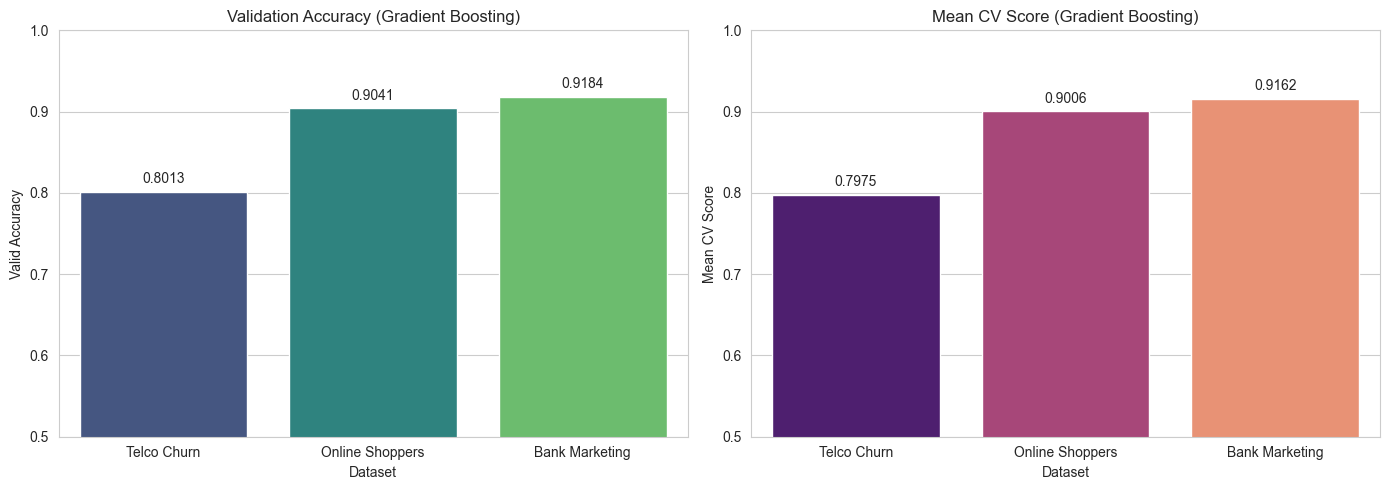

In [ ]:
master_table = df_results.pivot(index='Classifier', columns='Dataset', values='Valid')
master_table = master_table.sort_values(by="Bank Marketing", ascending=False)

print("TABELLE: VALIDATION ACCURACY ÜBERSICHT")
display(master_table.style.highlight_max(color='lightgreen', axis=0).format("{:.4f}"))

## 4. Visualisierung

Visualisierung der Validation Accuracy, da diese die entscheidende Metrik für die Auswahl des besten Modells ist.

In [ ]:
plt.figure(figsize=(14, 8))
ax = sns.barplot(x="Dataset", y="Valid", hue="Classifier", data=df_results, palette="muted")

# Werte über den Balken anzeigen
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=9, rotation=45)

plt.title("Gesamtvergleich: Validation Accuracy aller Modelle", fontsize=16)
plt.ylabel("Accuracy Score")
plt.ylim(0.65, 1.0) # Fokus auf den relevanten Bereich
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()